# Predikcija srčanog udara - SIAP projekat

**Autori:** Marija Tadić (E9 12/2024), Nevena Đukin (E2 145/2024)

Ovaj notebook implementira ceo pipeline iz predloga projekta: predikciju srčanih
oboljenja primenom mašinskog učenja nad **dva nezavisna skupa podataka** -
*Cleveland Heart Disease* i *Framingham Heart Study*.

### Važna metodološka napomena
Cleveland i Framingham se **NE spajaju** i njihovi rezultati se **ne porede direktno**
preko jedne metrike. Razlog:
- **Cleveland** je *dijagnostički* problem - `target` = da li pacijent trenutno ima
  srčano oboljenje (na osnovu kliničkih nalaza tipa EKG, ST-depresija, tip bola u grudima).
- **Framingham** je *prognostički* problem - `TenYearCHD` = rizik da pacijent razvije
  srčano oboljenje **u narednih 10 godina** (na osnovu životnih i bazičnih kliničkih faktora).

To su različiti zadaci sa različitim feature space-om i različitom baznom stopom pozitiva,
pa se vode kao dva odvojena eksperimenta i porede **na nivou zaključaka** (koji faktori dominiraju,
kako se ponaša balansiranje klasa), a ne na nivou apsolutnog F1/AUC.

Inicijalnu analizu značajnosti atributa radimo statistički
(t-test/Mann-Whitney, χ², mutual information, korelacija), a SHAP primenjujemo nakon
treniranja, nad najboljim modelom.


## Sadržaj

0. Setup i konfiguracija
1. Učitavanje podataka (Cleveland + Framingham, odvojeno)
2. EDA i statistička analiza značajnosti atributa
3. Preprocessing pipeline (sa zaštitom od curenja podataka)
4. HRFLM - custom hibridni estimator (Random Forest + linearni model)
5. Definicija modela
6. Evaluaciona funkcija (StratifiedKFold CV + holdout test)
7. Eksperiment: Cleveland
8. Eksperiment: Framingham (+ tretman disbalansa klasa)
9. SHAP interpretabilnost
10. KMeans klasterovanje i profilisanje pacijenata


## 0. Setup i konfiguracija



In [1]:
!pip install -q ucimlrepo scikit-learn pandas numpy matplotlib seaborn scipy imbalanced-learn shap xgboost catboost

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve,
                             precision_recall_curve, silhouette_score,
                             ConfusionMatrixDisplay)

from sklearn.base import BaseEstimator, ClassifierMixin

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    print("XGBoost nije dostupan:", e)

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except Exception as e:
    HAS_CAT = False
    print("CatBoost nije dostupan:", e)

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
    HAS_IMB = True
except Exception as e:
    HAS_IMB = False
    print("imbalanced-learn nije dostupan:", e)

try:
    import shap
    HAS_SHAP = True
except Exception as e:
    HAS_SHAP = False
    print("SHAP nije dostupan:", e)

# Globalni seed za reproduktivnost
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)

## 1. Učitavanje podataka

### 1.1 Cleveland Heart Disease
303 zapisa, 13 atributa + ciljna varijabla `num` (0–4). Vrednost `num > 0` znači prisustvo
oboljenja, pa ciljnu varijablu **binarizujemo** na {0, 1}. Nedostajuće vrednosti postoje u
kolonama `ca` i `thal`.


In [29]:
import os

def load_cleveland(local="../data/processed.cleveland.data"):
    cols = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
            "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]

    if os.path.exists(local):
        df = pd.read_csv(local, header=None, names=cols, na_values="?")
        y = (df["num"] > 0).astype(int)
        return df.drop(columns=["num"]), y


X_cl, y_cl = load_cleveland()
print("Cleveland oblik:", X_cl.shape)
print("Raspodela klasa:\n", y_cl.value_counts(normalize=True).round(3))
X_cl.head()

Cleveland oblik: (303, 13)
Raspodela klasa:
 num
0    0.541
1    0.459
Name: proportion, dtype: float64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0


Definišemo tipove kolona. Iako su `cp`, `restecg`, `slope`, `thal`, `ca` numerički
kodirane, semantički su **kategorijske** (kodovi, ne kontinuirane veličine) i tako ih tretiramo.


In [4]:
# Kontinuirani (numerički) atributi
num_cols_cl = ["age", "trestbps", "chol", "thalach", "oldpeak"]
# Kategorijski atributi (binarni i nominalni kodovi)
cat_cols_cl = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

print("Nedostajuće vrednosti po koloni:")
print(X_cl[num_cols_cl + cat_cols_cl].isna().sum())

Nedostajuće vrednosti po koloni:
age         0
trestbps    0
chol        0
thalach     0
oldpeak     0
sex         0
cp          0
fbs         0
restecg     0
exang       0
slope       0
ca          4
thal        2
dtype: int64


### 1.2 Framingham Heart Study

Skup podataka sadrži 4240 zapisa i 15 atributa, pri čemu je ciljna varijabla TenYearCHD. Podaci su disbalansirani, sapribližno 15% pozitivnih slučajeva, zbog čega su u daljoj analizi primenjene tehnike za tretiranje neravnoteže klasa (class_weight i SMOTE). U više kolona prisutne su nedostajuće vrednosti, uključujući glucose, education, BPMeds, totChol, cigsPerDay, BMI i heartRate.

Podaci su dostupni u datoteci data/framingham.csv, preuzetoj iz Kaggle skupa podataka Framingham Heart Study, što omogućava izvršavanje notebook-a bez internet konekcije.


In [33]:
def load_framingham(path="../data/framingham.csv"):
    df = pd.read_csv(path)
    return df

try:
    df_fr = load_framingham()
    y_fr = df_fr["TenYearCHD"].astype(int)
    X_fr = df_fr.drop(columns=["TenYearCHD"])
    print("Framingham oblik:", X_fr.shape)
    print("Raspodela klasa:\n", y_fr.value_counts(normalize=True).round(3))
    display(X_fr.head())
except FileNotFoundError:
    print("framingham.csv nije pronađen u ./data.")
    X_fr, y_fr = None, None

Framingham oblik: (4240, 15)
Raspodela klasa:
 TenYearCHD
0    0.848
1    0.152
Name: proportion, dtype: float64


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0


In [6]:
# Tipovi kolona za Framingham
num_cols_fr = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP",
               "BMI", "heartRate", "glucose"]
cat_cols_fr = ["male", "education", "currentSmoker", "BPMeds",
               "prevalentStroke", "prevalentHyp", "diabetes"]

if X_fr is not None:
    # zadržavamo samo kolone koje stvarno postoje (robusnost na varijacije skupa)
    num_cols_fr = [c for c in num_cols_fr if c in X_fr.columns]
    cat_cols_fr = [c for c in cat_cols_fr if c in X_fr.columns]
    print("Nedostajuće vrednosti po koloni:")
    print(X_fr[num_cols_fr + cat_cols_fr].isna().sum())

Nedostajuće vrednosti po koloni:
age                  0
cigsPerDay          29
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
male                 0
education          105
currentSmoker        0
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
dtype: int64


## 2. EDA i statistička analiza značajnosti atributa

Cilj je da se pre modelovanja ispita struktura skupa podataka, raspodela atributa, prisustvo nedostajućih vrednosti, balans klasa i povezanost atributa sa ishodom. Ova faza predstavlja inicijalnu analizu podataka, dok se naprednije metode interpretacije, poput SHAP-a, primenjuju u kasnijim koracima..


In [54]:
import math


def eda_overview(X, y, num_cols, cat_cols, name=""):
    print("="*70)
    print("EDA pregled:", name)
    print("="*70)
    print("Broj zapisa:", len(X), "| Broj atributa:", X.shape[1])
    print("Balans ciljne varijable:")
    print(y.value_counts(normalize=True).round(3).to_string())

    # Raspodela ciljne varijable
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.countplot(x=y, ax=ax[0])
    ax[0].set_title(f"{name}: raspodela klasa")
    ax[0].set_xlabel("klasa")

    # Nedostajuće vrednosti
    miss = X[num_cols + cat_cols].isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    if len(miss) > 0:
        miss.plot(kind="barh", ax=ax[1])
        ax[1].set_title(f"{name}: udeo nedostajućih")
    else:
        ax[1].text(0.5, 0.5, "Nema nedostajućih", ha="center")
        ax[1].set_axis_off()
    plt.tight_layout(); plt.show()

    # Distribucije numeričkih atributa po klasi
    n = len(num_cols)
    ncols = 3                              # 3 grafika po redu
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        ax = axes[i]
        for cls in sorted(y.unique()):
            sns.kdeplot(X.loc[y == cls, col].dropna(), ax=ax,
                        label=f"klasa {cls}", fill=True, alpha=0.3)
        ax.set_title(col); ax.legend()

    # ugasi prazne ćelije ako n nije deljivo sa ncols
    for j in range(n, len(axes)):
        axes[j].set_axis_off()

    plt.suptitle(f"{name}: numerički atributi po klasi", y=1.02)
    plt.tight_layout()
    plt.show()

EDA pregled: Cleveland
Broj zapisa: 303 | Broj atributa: 13
Balans ciljne varijable:
num
0    0.541
1    0.459


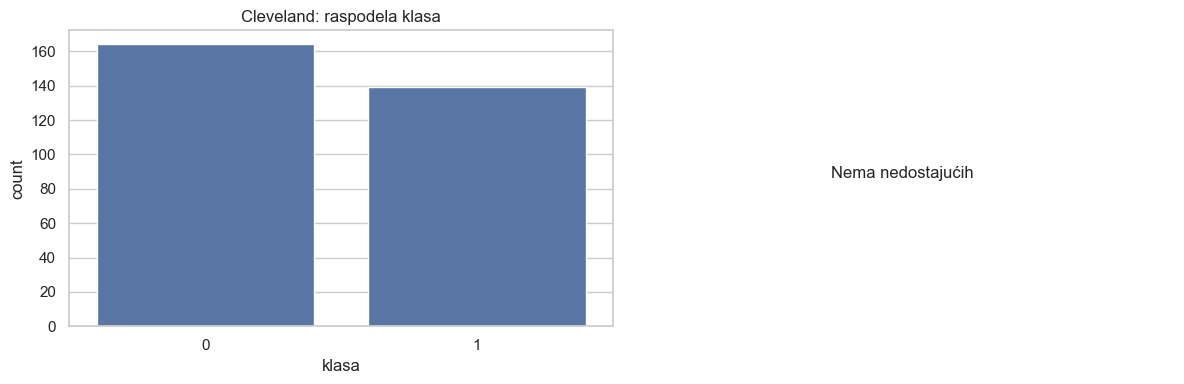

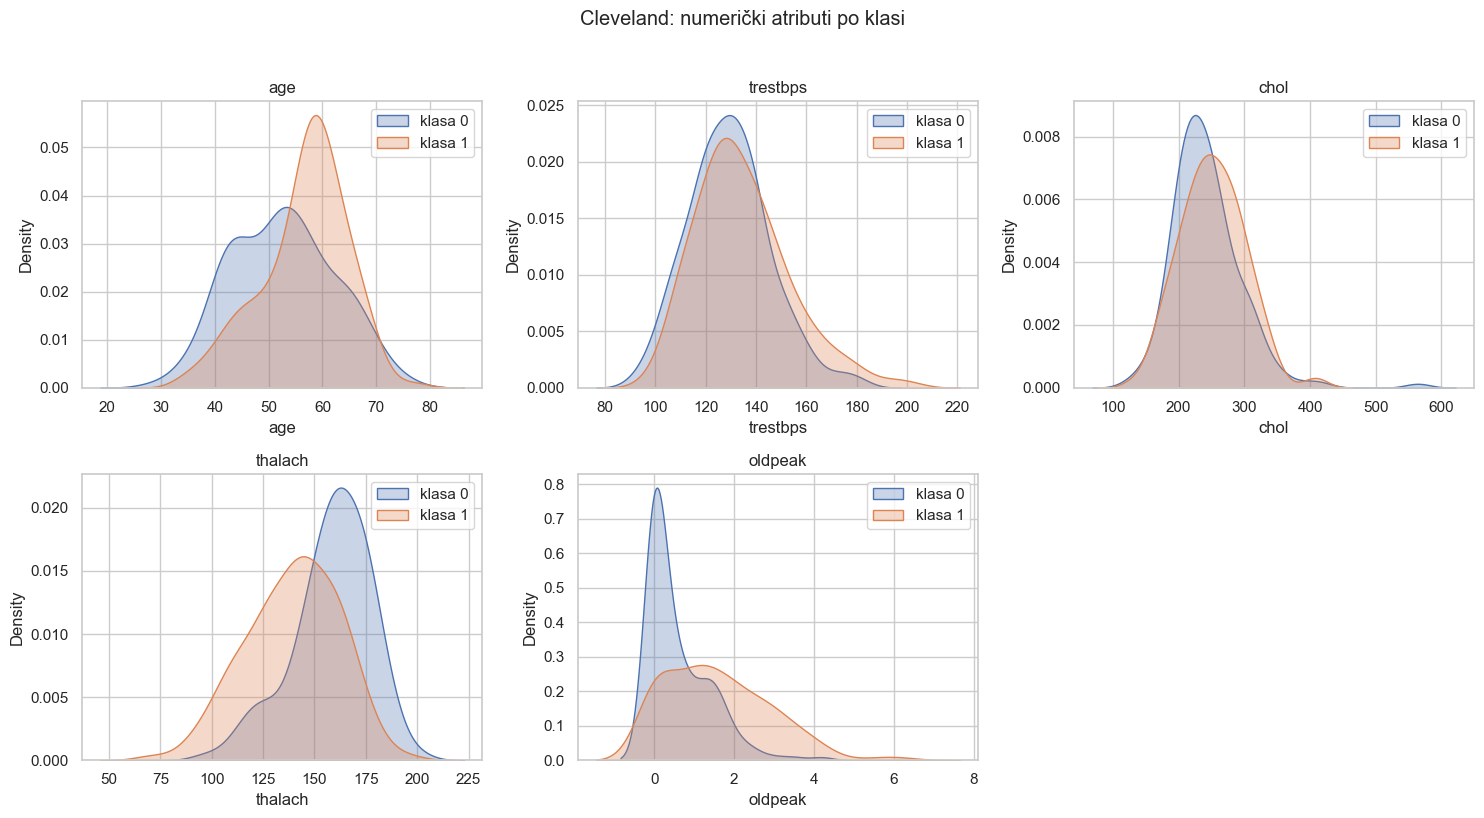

In [55]:
eda_overview(X_cl, y_cl, num_cols_cl, num_cols_cl + [], name="Cleveland")
# napomena: za KDE prikaz koristimo samo numeričke; kategorijske gledamo statistički ispod

EDA pregled: Framingham
Broj zapisa: 4240 | Broj atributa: 15
Balans ciljne varijable:
TenYearCHD
0    0.848
1    0.152


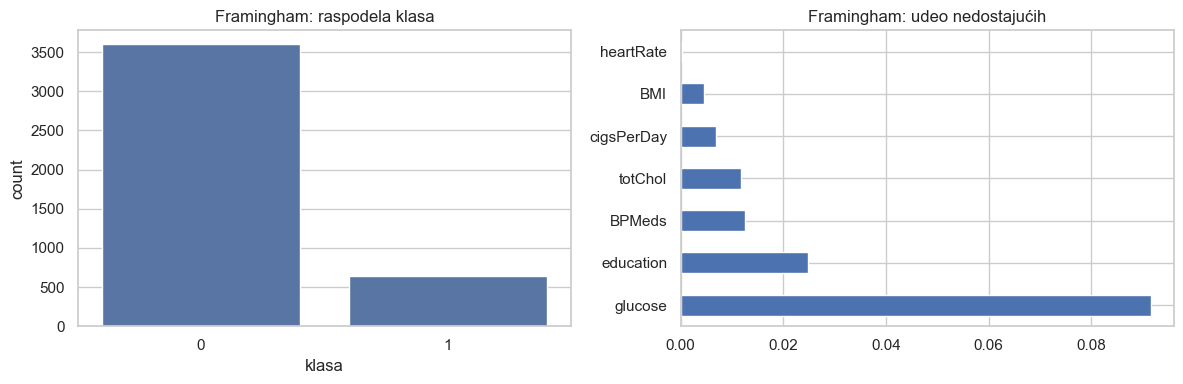

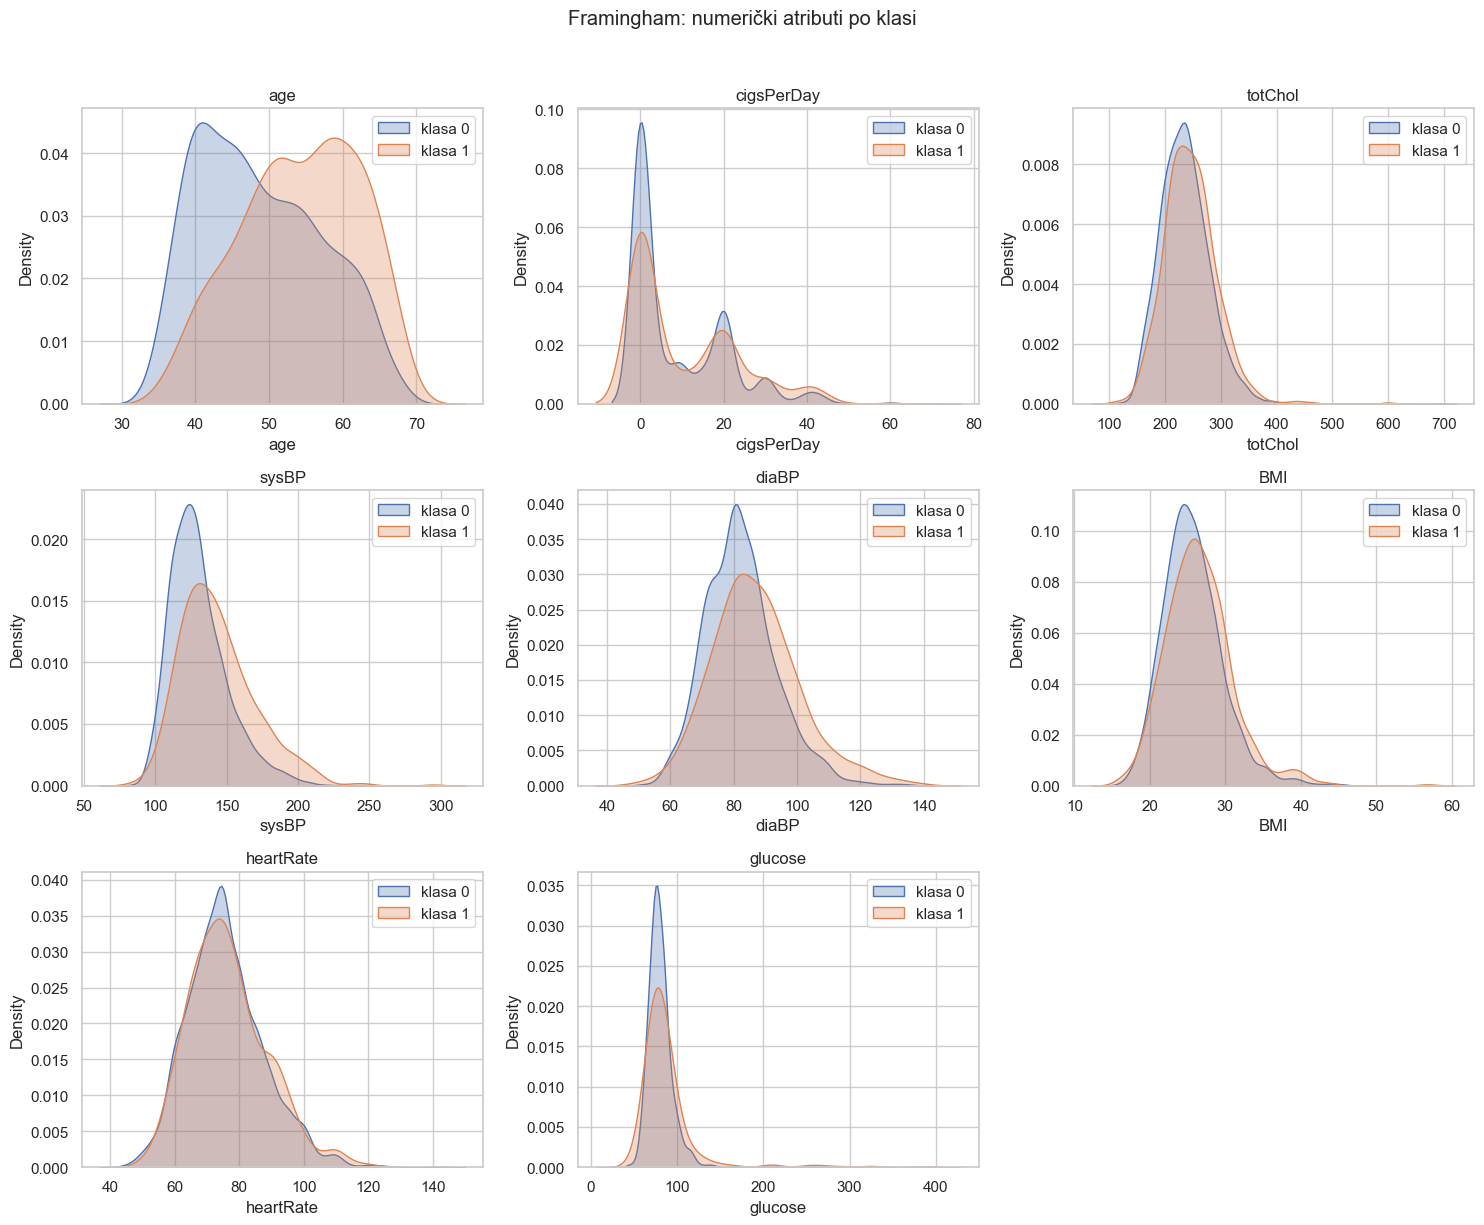

In [56]:
if X_fr is not None:
    eda_overview(X_fr, y_fr, num_cols_fr, cat_cols_fr, name="Framingham")

### 2.1 Statistički testovi značajnosti

Za procenu značajnosti atributa korišćeni su Mann–Whitney U test za numeričke atribute i χ² test nezavisnosti za kategorijske atribute. Dodatno je primenjena mutual information mera, koja omogućava otkrivanje i nelinearnih veza između atributa i ciljne varijable.


In [34]:
def significance_tests(X, y, num_cols, cat_cols, name=""):
    rows = []
    # Numerički -> Mann-Whitney U
    for col in num_cols:
        a = X.loc[y == 1, col].dropna()
        b = X.loc[y == 0, col].dropna()
        if len(a) > 0 and len(b) > 0:
            stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
            rows.append([col, "numerički", "Mann-Whitney", round(p, 5)])
    # Kategorijski -> chi-square
    for col in cat_cols:
        ct = pd.crosstab(X[col], y)
        if ct.shape[0] > 1:
            chi2, p, dof, _ = stats.chi2_contingency(ct)
            rows.append([col, "kategorijski", "chi-square", round(p, 5)])
    res = pd.DataFrame(rows, columns=["atribut", "tip", "test", "p_value"])
    res = res.sort_values("p_value").reset_index(drop=True)
    res["značajan_0.05"] = res["p_value"] < 0.05
    print(f"Statistički testovi — {name}")
    return res

sig_cl = significance_tests(X_cl, y_cl, num_cols_cl, cat_cols_cl, "Cleveland")
sig_cl

Statistički testovi — Cleveland


,atribut,tip,test,p_value,značajan_0.05
0,thalach,numerički,Mann-Whitney,0.00000,True
1,cp,kategorijski,chi-square,0.00000,True
2,sex,kategorijski,chi-square,0.00000,True
3,oldpeak,numerički,Mann-Whitney,0.00000,True
4,thal,kategorijski,chi-square,0.00000,True
5,ca,kategorijski,chi-square,0.00000,True
6,slope,kategorijski,chi-square,0.00000,True
7,exang,kategorijski,chi-square,0.00000,True
8,age,numerički,Mann-Whitney,0.00004,True
9,restecg,kategorijski,chi-square,0.00657,True


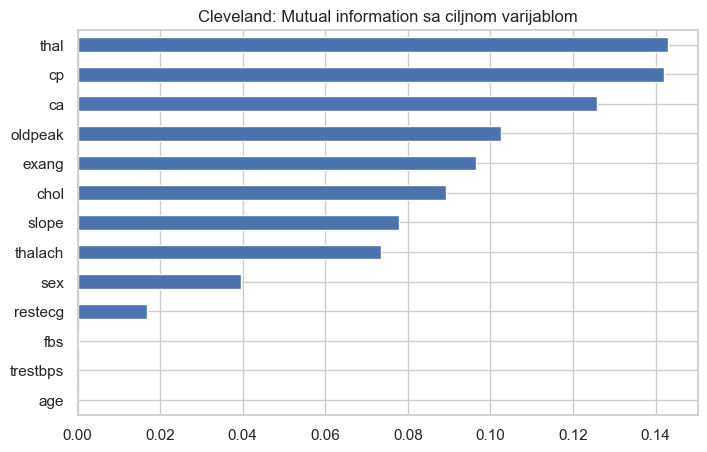

In [11]:
# Mutual information (zahteva imputirane numeričke ulaze) — Cleveland
def quick_mi(X, y, num_cols, cat_cols):
    Xi = X[num_cols + cat_cols].copy()
    for c in num_cols:
        Xi[c] = Xi[c].fillna(Xi[c].median())
    for c in cat_cols:
        Xi[c] = Xi[c].fillna(Xi[c].mode().iloc[0])
    discrete = [Xi.columns.get_loc(c) for c in cat_cols]
    mi = mutual_info_classif(Xi, y, discrete_features=discrete, random_state=RANDOM_STATE)
    return pd.Series(mi, index=Xi.columns).sort_values(ascending=False)

mi_cl = quick_mi(X_cl, y_cl, num_cols_cl, cat_cols_cl)
mi_cl.plot(kind="barh"); plt.gca().invert_yaxis()
plt.title("Cleveland: Mutual information sa ciljnom varijablom"); plt.show()

Statistički testovi — Framingham


,atribut,tip,test,p_value,značajan_0.05
0,age,numerički,Mann-Whitney,0.00000,True
1,totChol,numerički,Mann-Whitney,0.00000,True
2,sysBP,numerički,Mann-Whitney,0.00000,True
3,diaBP,numerički,Mann-Whitney,0.00000,True
4,BMI,numerički,Mann-Whitney,0.00000,True
5,BPMeds,kategorijski,chi-square,0.00000,True
6,education,kategorijski,chi-square,0.00000,True
7,male,kategorijski,chi-square,0.00000,True
8,diabetes,kategorijski,chi-square,0.00000,True
9,prevalentHyp,kategorijski,chi-square,0.00000,True


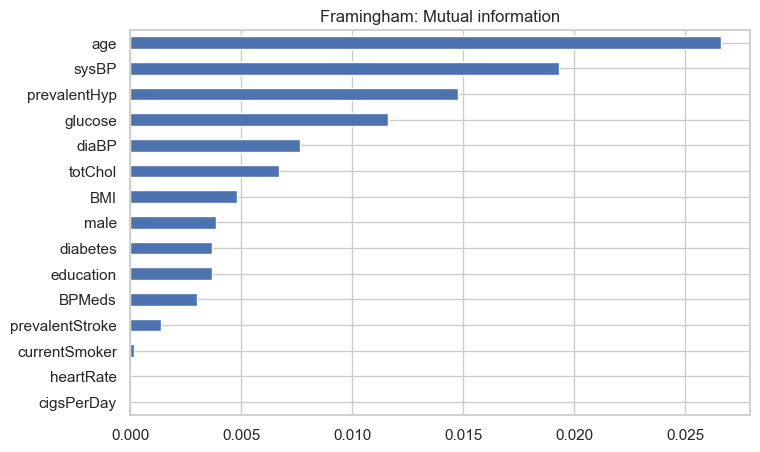

In [35]:
if X_fr is not None:
    sig_fr = significance_tests(X_fr, y_fr, num_cols_fr, cat_cols_fr, "Framingham")
    display(sig_fr)
    mi_fr = quick_mi(X_fr, y_fr, num_cols_fr, cat_cols_fr)
    mi_fr.plot(kind="barh"); plt.gca().invert_yaxis()
    plt.title("Framingham: Mutual information"); plt.show()

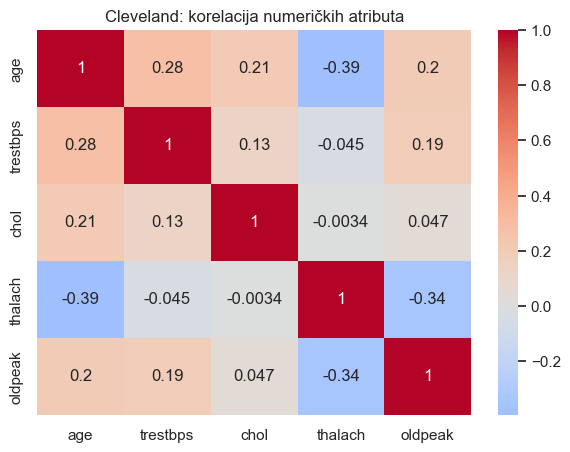

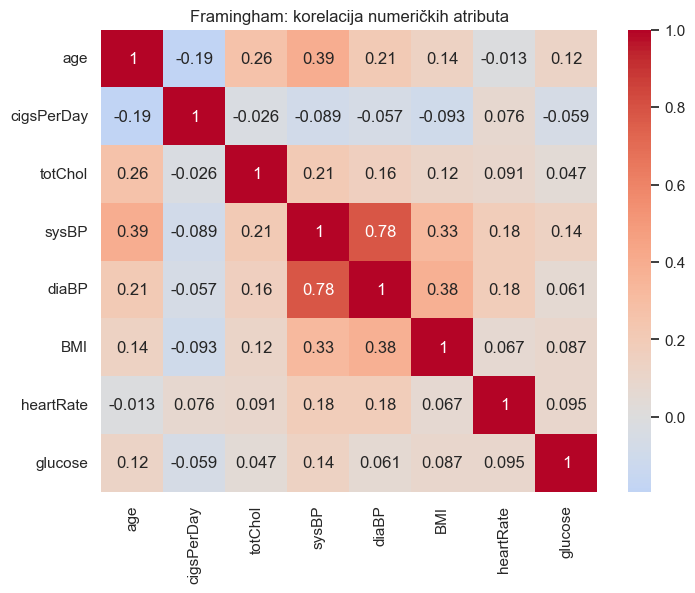

In [13]:
# Korelaciona matrica numeričkih atributa (detekcija multikolinearnosti)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(X_cl[num_cols_cl].corr(), annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Cleveland: korelacija numeričkih atributa"); plt.show()

if X_fr is not None:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(X_fr[num_cols_fr].corr(), annot=True, cmap="coolwarm", center=0, ax=ax)
    ax.set_title("Framingham: korelacija numeričkih atributa"); plt.show()


## 3. Preprocessing pipeline

Sve transformacije podataka implementirane su korišćenjem ColumnTransformer komponente unutar jedinstvenog Pipeline procesa. Na taj način se parametri transformacija uče isključivo na trening skupu u okviru svakog folda unakrsne validacije, čime se sprečava curenje podataka (data leakage) i obezbeđuje objektivna procena performansi modela.

Za numeričke atribute primenjena je imputacija nedostajućih vrednosti medijanom, nakon čega je izvršena standardizacija podataka korišćenjem StandardScaler metode. Za kategorijske atribute korišćena je imputacija najčešćom vrednošću (most-frequent), a zatim One-Hot kodiranje pomoću OneHotEncoder komponente. Generisan je gust (dense) izlaz kodiranih atributa kako bi se omogućila kompatibilnost sa HRFLM modelom i SHAP analizom.


In [14]:
def build_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ])

## 4. HRFLM - Hybrid Random Forest with Linear Model

Osnovna ideja modela je kombinovanje prednosti Random Forest algoritma i linearnog modela.

Najpre se trenira Random Forest model, a zatim se za svaki uzorak određuje u koji list svakog stabla on dospeva (rf.apply(X)). Na taj način dobija se nelinearna reprezentacija podataka koju je model naučio tokom obuke. Dobijeni identifikatori listova zatim se One-Hot kodiraju i koriste kao ulaz za logističku regresiju.

Logistička regresija na taj način uči težine nad obrascima i particijama prostora koje je prethodno otkrio Random Forest. Rezultat je hibridni model koji kombinuje sposobnost Random Forest-a da prepozna složene nelinearne odnose sa interpretabilnošću linearnog modela. Implementacija je u potpunosti kompatibilna sa scikit-learn okruženjem, pa se može koristiti unutar Pipeline-a, kao i sa metodama za unakrsnu validaciju i optimizaciju hiperparametara, poput cross_val_score i GridSearchCV.


In [15]:
class HRFLM(BaseEstimator, ClassifierMixin):
    # Hibrid: RandomForest (leaf embedding) + LogisticRegression
    def __init__(self, n_estimators=200, max_depth=None, C=1.0,
                 class_weight=None, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.C = C
        self.class_weight = class_weight
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X)
        self.rf_ = RandomForestClassifier(
            n_estimators=self.n_estimators, max_depth=self.max_depth,
            class_weight=self.class_weight, random_state=self.random_state, n_jobs=-1)
        self.rf_.fit(X, y)
        leaves = self.rf_.apply(X)  # (n_uzoraka, n_stabala)
        self.enc_ = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
        L = self.enc_.fit_transform(leaves)
        self.lr_ = LogisticRegression(
            C=self.C, max_iter=2000, class_weight=self.class_weight,
            random_state=self.random_state)
        self.lr_.fit(L, y)
        self.classes_ = self.rf_.classes_
        return self

    def _embed(self, X):
        X = np.asarray(X)
        return self.enc_.transform(self.rf_.apply(X))

    def predict(self, X):
        return self.lr_.predict(self._embed(X))

    def predict_proba(self, X):
        return self.lr_.predict_proba(self._embed(X))

## 5. Definicija modela

U eksperimentalnom delu korišćeni su modeli predviđeni istraživačkim planom: logistička regresija kao referentni (baseline) model, Naive Bayes, stablo odlučivanja (Decision Tree), SVM, Random Forest, XGBoost, CatBoost i HRFLM.

S obzirom na prisutnu neravnotežu klasa u Framingham skupu podataka, kod modela koji podržavaju ovu funkcionalnost korišćene su težine klasa (class_weight) kako bi se umanjio uticaj disbalansa na performanse modela. Za XGBoost model primenjen je parametar scale_pos_weight, čija je vrednost izračunata na osnovu odnosa između negativnih i pozitivnih primera u trening skupu.


In [16]:
def get_models(class_weight=None, scale_pos_weight=1.0):
    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=2000, class_weight=class_weight, random_state=RANDOM_STATE),
        "Naive Bayes": GaussianNB(),
        "Decision Tree": DecisionTreeClassifier(
            class_weight=class_weight, random_state=RANDOM_STATE),
        "SVM": SVC(probability=True, class_weight=class_weight, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(
            n_estimators=300, class_weight=class_weight,
            random_state=RANDOM_STATE, n_jobs=-1),
        "HRFLM": HRFLM(class_weight=class_weight, random_state=RANDOM_STATE),
    }
    if HAS_XGB:
        models["XGBoost"] = XGBClassifier(
            eval_metric="logloss", scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE, n_jobs=-1)
    if HAS_CAT:
        models["CatBoost"] = CatBoostClassifier(
            verbose=0, random_state=RANDOM_STATE,
            auto_class_weights=("Balanced" if class_weight == "balanced" else None))
    return models

## 6. Evaluaciona funkcija

Podaci su najpre podeljeni na trening i test skup u odnosu 80:20, pri čemu je podela izvršena stratifikovano kako bi se sačuvala originalna raspodela klasa. Za procenu performansi modela na trening skupu korišćena je petostruka stratifikovana unakrsna validacija (5-fold Stratified K-Fold), što omogućava pouzdaniju i stabilniju evaluaciju rezultata.

Glavna metrika za poređenje modela bila je F1 mera, jer istovremeno uzima u obzir preciznost i odziv. Pored nje, analizirani su i AUC, preciznost (precision), odziv (recall) i matrica konfuzije kako bi se dobila što potpunija slika o performansama svakog modela. Za sve modele prikazane su ROC i Precision–Recall krive, pri čemu su Precision–Recall krive posebno značajne zbog neravnomerne zastupljenosti klasa u podacima.

Kada je korišćena SMOTE metoda za balansiranje klasa, ona je primenjena isključivo na trening podatke unutar svakog folda unakrsne validacije. Implementacija kroz imblearn.Pipeline omogućava da se ovaj postupak odvija automatski i bez curenja informacija iz testnih podataka, čime se obezbeđuje realnija procena performansi modela.


In [17]:
def make_pipe(preprocessor, model, use_smote):
    if use_smote:
        if not HAS_IMB:
            raise RuntimeError("imbalanced-learn nije instaliran, a use_smote=True")
        return ImbPipeline([
            ("prep", preprocessor),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("clf", model),
        ])
    return Pipeline([("prep", preprocessor), ("clf", model)])


def evaluate_models(X, y, num_cols, cat_cols, use_smote=False,
                    class_weight=None, name=""):
    X = X[num_cols + cat_cols].copy()
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

    # scale_pos_weight za XGBoost (samo kada balansiramo)
    pos = (y_tr == 1).sum(); neg = (y_tr == 0).sum()
    spw = (neg / pos) if (class_weight == "balanced" and pos > 0) else 1.0

    models = get_models(class_weight=class_weight, scale_pos_weight=spw)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    results, fitted, proba_store = [], {}, {}
    for mname, model in models.items():
        prep = build_preprocessor(num_cols, cat_cols)
        pipe = make_pipe(prep, model, use_smote)
        # Cross-Validation F1 mera na trening skupu
        cv_f1 = cross_val_score(pipe, X_tr, y_tr, cv=skf, scoring="f1", n_jobs=-1)
        # finalni fit + evaluacija na holdout test skupu
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)
        y_proba = pipe.predict_proba(X_te)[:, 1]
        results.append({
            "Model": mname,
            "CV F1 (mean)": round(cv_f1.mean(), 4),
            "CV F1 (std)": round(cv_f1.std(), 4),
            "Test F1": round(f1_score(y_te, y_pred), 4),
            "Preciznost": round(precision_score(y_te, y_pred, zero_division=0), 4),
            "Odziv": round(recall_score(y_te, y_pred), 4),
            "Tačnost": round(accuracy_score(y_te, y_pred), 4),
            "AUC": round(roc_auc_score(y_te, y_proba), 4),
        })
        fitted[mname] = pipe
        proba_store[mname] = y_proba

    res_df = pd.DataFrame(results).sort_values("Test F1", ascending=False).reset_index(drop=True)

    # ROC i PR krive za sve modele
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    for mname, yp in proba_store.items():
        fpr, tpr, _ = roc_curve(y_te, yp)
        ax[0].plot(fpr, tpr, label=f"{mname} (AUC={roc_auc_score(y_te, yp):.3f})")
        prec, rec, _ = precision_recall_curve(y_te, yp)
        ax[1].plot(rec, prec, label=mname)
    ax[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].set_title(f"{name}: ROC")
    ax[0].legend(fontsize=8)
    ax[1].set_xlabel("Odziv"); ax[1].set_ylabel("Preciznost")
    ax[1].set_title(f"{name}: Precision-Recall"); ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

    return res_df, fitted, (X_tr, X_te, y_tr, y_te)

In [18]:
def plot_confusion(fitted, data, model_name, name=""):
    X_tr, X_te, y_tr, y_te = data
    y_pred = fitted[model_name].predict(X_te)
    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues", colorbar=False)
    plt.title(f"{name}: matrica konfuzije — {model_name}"); plt.show()

## 7. Eksperiment: Cleveland

Cleveland je skoro balansiran, pa ne koristimo SMOTE niti `class_weight`.


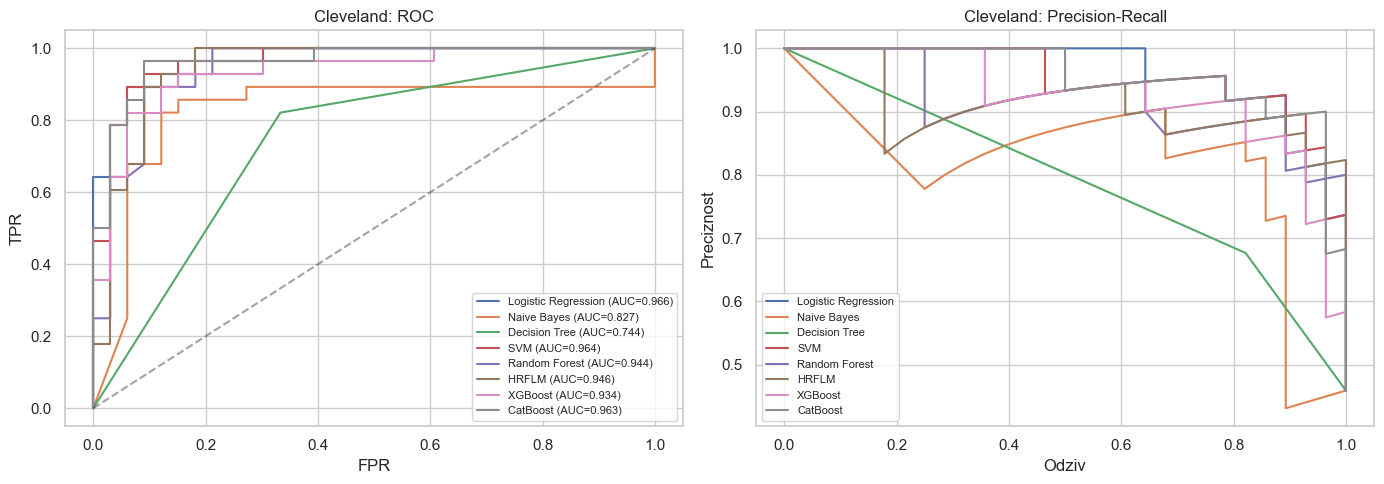

,Model,CV F1 (mean),CV F1 (std),Test F1,Preciznost,Odziv,Tačnost,AUC
0,CatBoost,0.7808,0.0204,0.9000,0.8438,0.9643,0.9016,0.9632
1,Logistic Regression,0.8245,0.0069,0.8814,0.8387,0.9286,0.8852,0.9665
2,HRFLM,0.7719,0.0234,0.8814,0.8387,0.9286,0.8852,0.9459
3,SVM,0.7893,0.0271,0.8814,0.8387,0.9286,0.8852,0.9643
4,Random Forest,0.7958,0.0363,0.8667,0.8125,0.9286,0.8689,0.9443
5,XGBoost,0.7707,0.0269,0.8387,0.7647,0.9286,0.8361,0.9340
6,Naive Bayes,0.7495,0.0215,0.7463,0.6410,0.8929,0.7213,0.8268
7,Decision Tree,0.6768,0.0420,0.7419,0.6765,0.8214,0.7377,0.7440


In [19]:
res_cl, fitted_cl, data_cl = evaluate_models(
    X_cl, y_cl, num_cols_cl, cat_cols_cl, use_smote=False, class_weight=None, name="Cleveland")
res_cl

Najbolji model (Cleveland): CatBoost


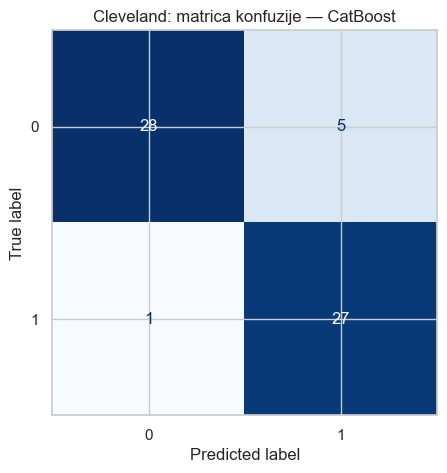

In [20]:
best_cl = res_cl.iloc[0]["Model"]
print("Najbolji model (Cleveland):", best_cl)
plot_confusion(fitted_cl, data_cl, best_cl, name="Cleveland")

## 8. Eksperiment: Framingham (+ tretman disbalansa)

Framingham skup podataka karakteriše izražena neravnoteža klasa, budući da pozitivni slučajevi čine svega oko 15% svih ispitanika. Zbog toga su u istraživanju upoređena tri pristupa:
- korišćenje originalnih podataka bez dodatnog tretmana disbalansa
- primena težina klasa (class_weight="balanced")
- primena SMOTE metode za generisanje sintetičkih uzoraka manjinske klase.

Prilikom evaluacije modela poseban fokus stavljen je na odziv (recall) i PR-AUC metriku. U kontekstu predviđanja rizika od koronarne bolesti srca, važnije je prepoznati što veći broj rizičnih pacijenata nego postići visoku tačnost po svaku cenu, jer lažno negativne predikcije mogu dovesti do toga da pacijenti sa povećanim rizikom ostanu neidentifikovani.


>>> Framingham — bez tretmana disbalansa


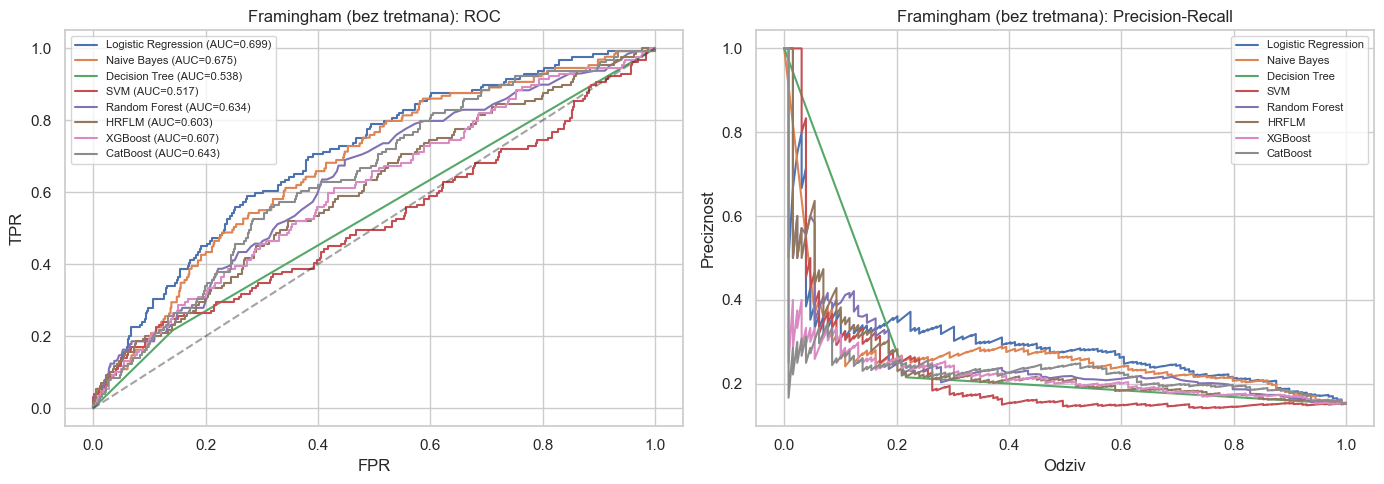

,Model,CV F1 (mean),CV F1 (std),Test F1,Preciznost,Odziv,Tačnost,AUC
0,Decision Tree,0.2760,0.0224,0.2162,0.2154,0.2171,0.7606,0.5376
1,Naive Bayes,0.2559,0.0234,0.1693,0.2667,0.1240,0.8149,0.6754
2,HRFLM,0.2067,0.0313,0.1585,0.3714,0.1008,0.8373,0.6031
3,XGBoost,0.1992,0.0342,0.1512,0.3023,0.1008,0.8278,0.6072
4,CatBoost,0.1622,0.0383,0.1039,0.3200,0.0620,0.8373,0.6426
5,Random Forest,0.1306,0.0112,0.0966,0.4375,0.0543,0.8455,0.6344
6,Logistic Regression,0.1640,0.0478,0.0822,0.3529,0.0465,0.8420,0.6994
7,SVM,0.0334,0.0216,0.0597,0.8000,0.0310,0.8514,0.5170


In [21]:
if X_fr is not None:
    print(">>> Framingham - bez tretmana disbalansa")
    res_fr_base, fitted_fr_base, data_fr = evaluate_models(
        X_fr, y_fr, num_cols_fr, cat_cols_fr,
        use_smote=False, class_weight=None, name="Framingham (bez tretmana)")
    display(res_fr_base)

>>> Framingham — class_weight='balanced'


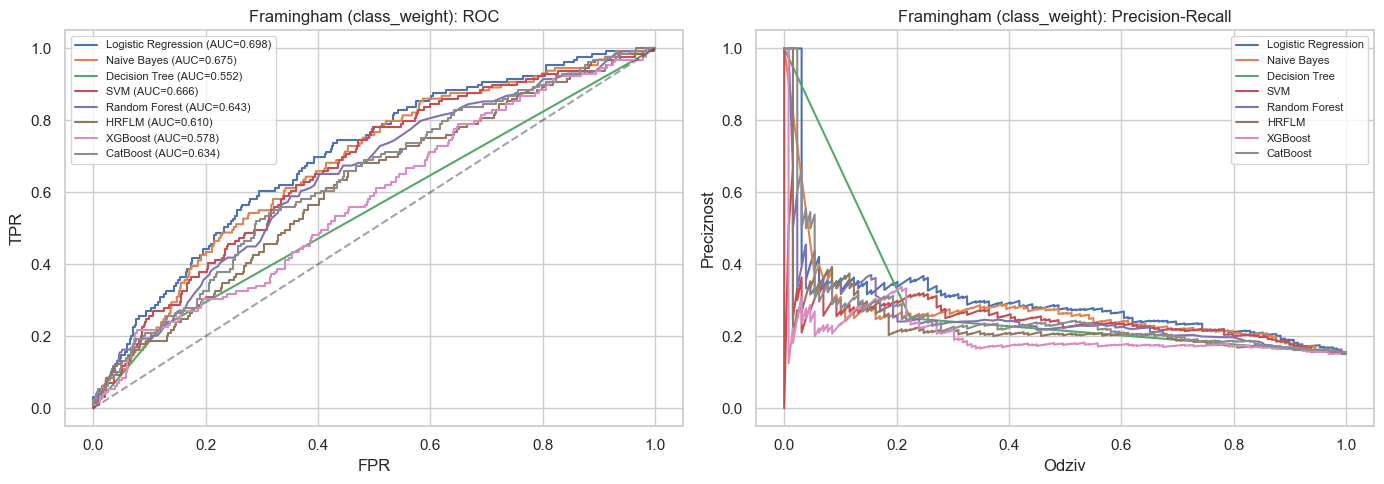

,Model,CV F1 (mean),CV F1 (std),Test F1,Preciznost,Odziv,Tačnost,AUC
0,Logistic Regression,0.3947,0.0311,0.3586,0.2549,0.6047,0.6710,0.6981
1,SVM,0.3823,0.0371,0.3190,0.2302,0.5194,0.6627,0.6657
2,CatBoost,0.3463,0.0200,0.2642,0.2222,0.3256,0.7241,0.6340
3,XGBoost,0.2580,0.0239,0.2445,0.2800,0.2171,0.7960,0.5785
4,Decision Tree,0.2046,0.0285,0.2367,0.2500,0.2248,0.7795,0.5519
5,HRFLM,0.2527,0.0246,0.1808,0.3333,0.1240,0.8290,0.6101
6,Naive Bayes,0.2559,0.0234,0.1693,0.2667,0.1240,0.8149,0.6754
7,Random Forest,0.0736,0.0228,0.0441,0.4286,0.0233,0.8467,0.6430


In [22]:
if X_fr is not None:
    print(">>> Framingham - class_weight='balanced'")
    res_fr_cw, fitted_fr_cw, _ = evaluate_models(
        X_fr, y_fr, num_cols_fr, cat_cols_fr,
        use_smote=False, class_weight="balanced", name="Framingham (class_weight)")
    display(res_fr_cw)

>>> Framingham - SMOTE


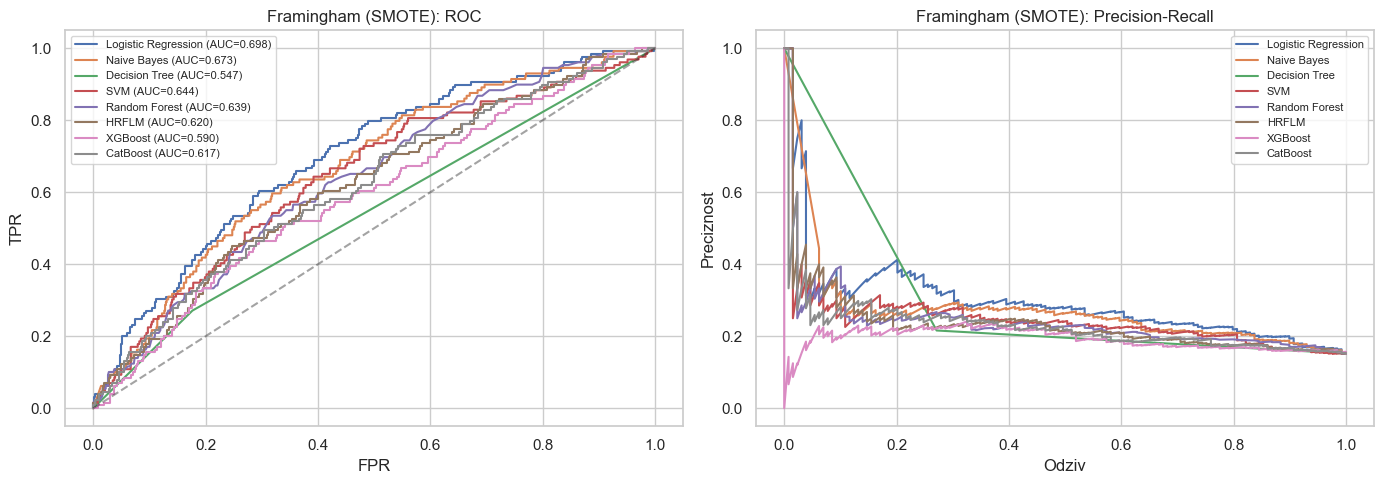

,Model,CV F1 (mean),CV F1 (std),Test F1,Preciznost,Odziv,Tačnost,AUC
0,Logistic Regression,0.3802,0.0288,0.3587,0.2524,0.6202,0.6627,0.6977
1,SVM,0.3194,0.0165,0.3177,0.2392,0.4729,0.6910,0.6443
2,Naive Bayes,0.3298,0.0369,0.2734,0.2756,0.2713,0.7807,0.6729
3,Decision Tree,0.2486,0.0190,0.2405,0.2160,0.2713,0.7394,0.5473
4,CatBoost,0.2676,0.0232,0.2000,0.2593,0.1628,0.8019,0.6169
5,Random Forest,0.2687,0.0223,0.1827,0.2405,0.1473,0.7995,0.6387
6,XGBoost,0.2303,0.0181,0.1818,0.2198,0.1550,0.7877,0.5904
7,HRFLM,0.2532,0.0342,0.1753,0.2615,0.1318,0.8113,0.6200


In [38]:
if X_fr is not None and HAS_IMB:
    print(">>> Framingham - SMOTE")
    res_fr_smote, fitted_fr_smote, data_fr_smote = evaluate_models(
        X_fr, y_fr, num_cols_fr, cat_cols_fr,
        use_smote=True, class_weight=None, name="Framingham (SMOTE)")
    display(res_fr_smote)

In [40]:
# Poređenje tri strategije po odzivu i F1
if X_fr is not None:
    comp = pd.DataFrame({
        "bez tretmana": res_fr_base.set_index("Model")[["Test F1", "Odziv", "AUC"]].mean(),
        "class_weight": res_fr_cw.set_index("Model")[["Test F1", "Odziv", "AUC"]].mean(),
    })
    if HAS_IMB:
        comp["SMOTE"] = res_fr_smote.set_index("Model")[["Test F1", "Odziv", "AUC"]].mean()
    print("Prosek metrika preko svih modela po strategiji:")
    display(comp.round(3))

Prosek metrika preko svih modela po strategiji:


,bez tretmana,class_weight,SMOTE
Test F1,0.130,0.227,0.241
Odziv,0.092,0.270,0.279
AUC,0.615,0.632,0.629


## 9. SHAP interpretabilnost

Po završetku treniranja modela sprovedena je SHAP analiza nad najboljim modelom zasnovanim na stablima. Korišćenjem TreeExplainer metode analiziran je doprinos svakog atributa konačnim predikcijama modela.

SHAP summary prikaz omogućio je uvid u najuticajnije atribute i smer njihovog uticaja na procenjeni rizik, dok je rang-lista atributa korišćena za poređenje sa rezultatima prethodno sprovedene statističke analize.


SHAP nad modelom: CatBoost


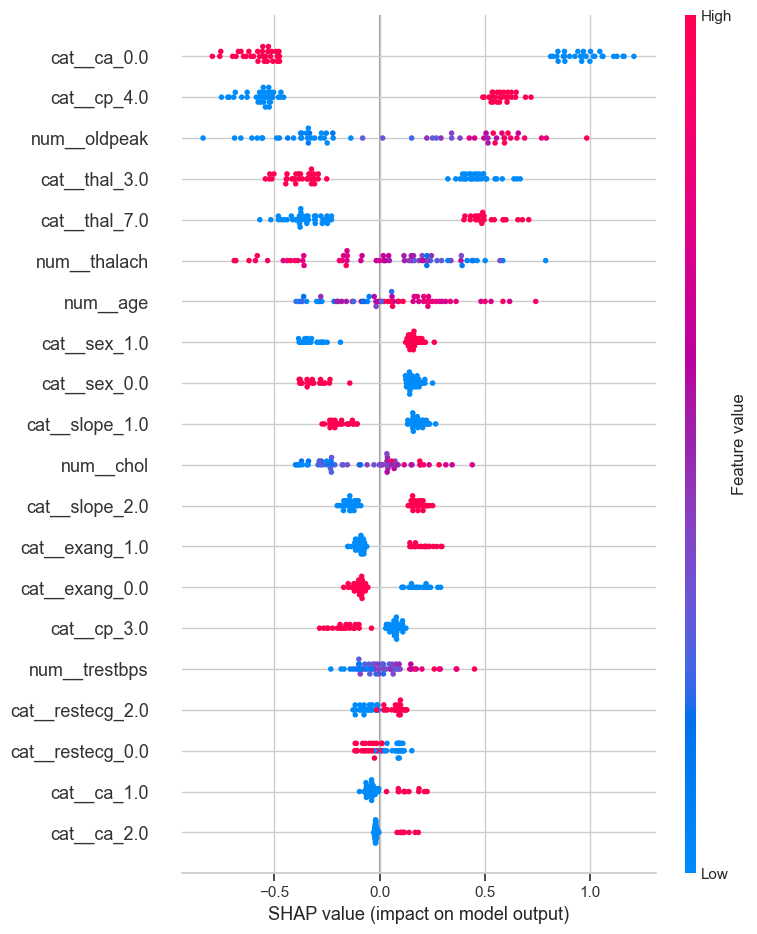

'CatBoost'

In [57]:
def run_shap(fitted, data, num_cols, cat_cols, prefer=("CatBoost", "XGBoost", "Random Forest")):
    if not HAS_SHAP:
        print("SHAP nije dostupan."); return
    X_tr, X_te, y_tr, y_te = data
    model_name = next((m for m in prefer if m in fitted), None)
    if model_name is None:
        print("Nema pogodnog tree modela za TreeExplainer."); return
    pipe = fitted[model_name]
    prep = pipe.named_steps["prep"]
    clf = pipe.named_steps["clf"]
    X_te_t = prep.transform(X_te)
    feat_names = prep.get_feature_names_out()
    explainer = shap.TreeExplainer(clf)
    sv = explainer.shap_values(X_te_t)
    if isinstance(sv, list):
        sv = sv[1]
    print(f"SHAP nad modelom: {model_name}")
    shap.summary_plot(sv, X_te_t, feature_names=feat_names, show=True)
    return model_name

run_shap(fitted_cl, data_cl, num_cols_cl, cat_cols_cl)

SHAP nad modelom: CatBoost


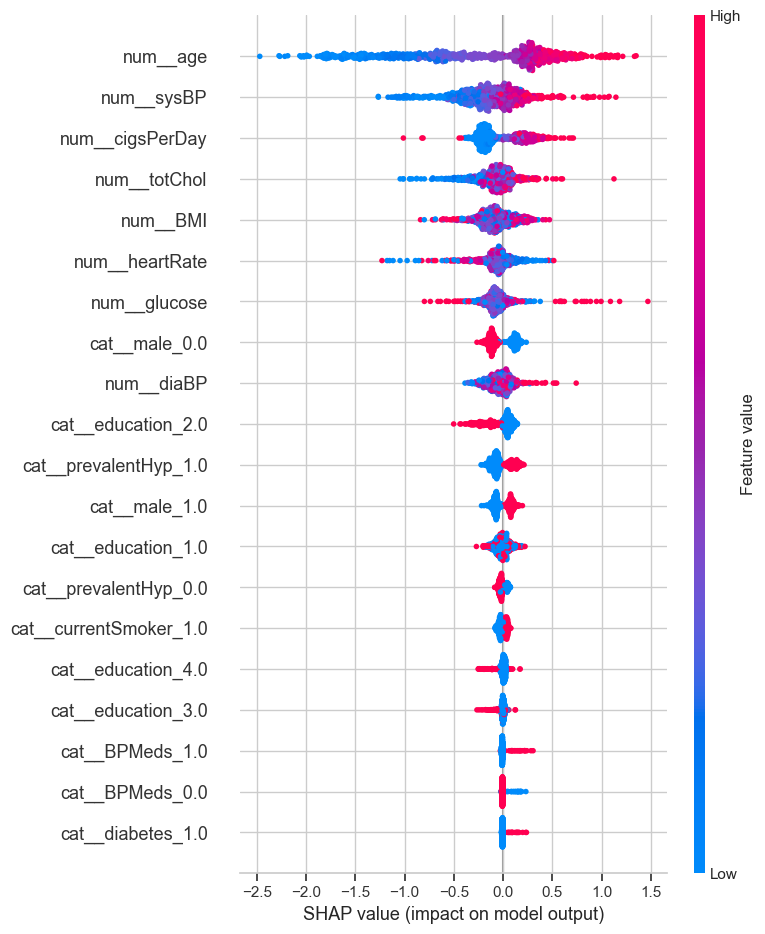

In [58]:
if X_fr is not None:
    run_shap(fitted_fr_cw, data_fr, num_cols_fr, cat_cols_fr)

## 10. KMeans klasterovanje i profilisanje pacijenata

Nenadgledano grupisanje pacijenata po sličnim karakteristikama. Radimo na
**skaliranim** atributima (bez ciljne varijable). Broj klastera biramo kombinacijom
*elbow* metode (inercija) i *silhouette* skora, zatim profilišemo klastere u odnosu
na ciljnu varijablu i ključne atribute.


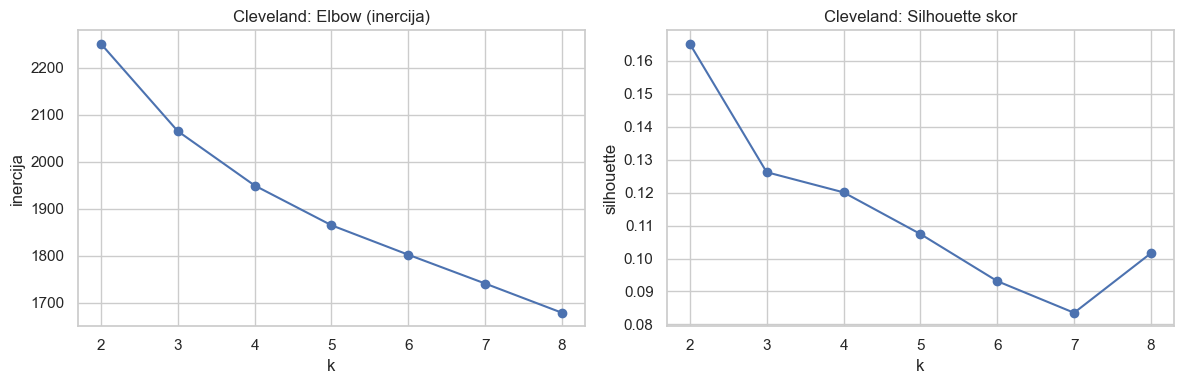

Cleveland: izabrano k = 2 (max silhouette)
Cleveland: udeo pozitiva po klasteru:


klaster
0    0.745
1    0.223
Name: target, dtype: float64

Cleveland: prosečne vrednosti numeričkih atributa po klasteru:


,age,trestbps,chol,thalach,oldpeak
klaster,,,,,
0,60.02,136.86,257.01,133.62,1.75
1,49.83,127.42,238.17,162.80,0.45


In [72]:
def kmeans_analysis(X, y, num_cols, cat_cols, name=""):
    prep = build_preprocessor(num_cols, cat_cols)
    Xk = prep.fit_transform(X[num_cols + cat_cols])

    Ks = range(2, 9)
    inertias, sils = [], []
    for k in Ks:
        km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
        labels = km.fit_predict(Xk)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(Xk, labels))

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(list(Ks), inertias, "o-"); ax[0].set_title(f"{name}: Elbow (inercija)")
    ax[0].set_xlabel("k"); ax[0].set_ylabel("inercija")
    ax[1].plot(list(Ks), sils, "o-"); ax[1].set_title(f"{name}: Silhouette skor")
    ax[1].set_xlabel("k"); ax[1].set_ylabel("silhouette")
    plt.tight_layout(); plt.show()

    best_k = list(Ks)[int(np.argmax(sils))]
    print(f"{name}: izabrano k = {best_k} (max silhouette)")

    km = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
    clusters = km.fit_predict(Xk)

    prof = X[num_cols].copy()
    prof["klaster"] = clusters
    prof["target"] = y.values
    summary = prof.groupby("klaster").agg(
        ["mean"]).round(2)
    rate = prof.groupby("klaster")["target"].mean().round(3)
    print(f"{name}: udeo pozitiva po klasteru:")
    display(rate)
    print(f"{name}: prosečne vrednosti numeričkih atributa po klasteru:")
    display(prof.groupby("klaster")[num_cols].mean().round(2))
    return clusters

_ = kmeans_analysis(X_cl, y_cl, num_cols_cl, cat_cols_cl, name="Cleveland")

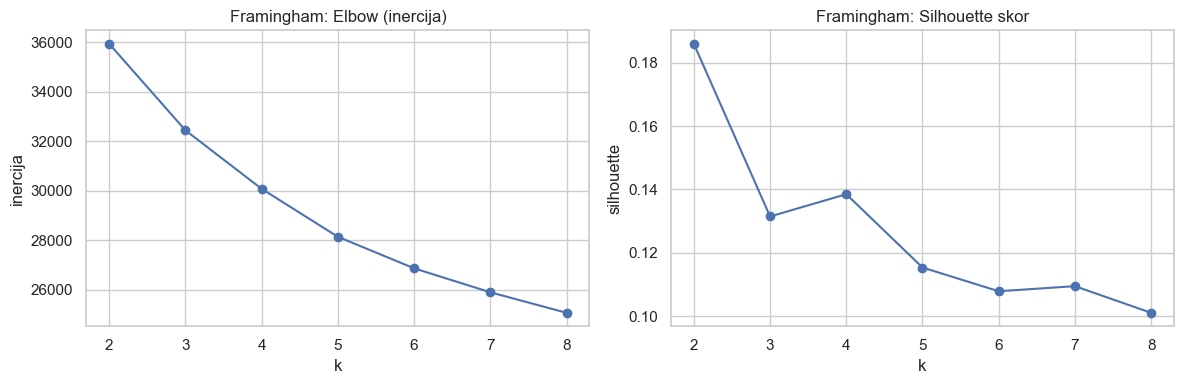

Framingham: izabrano k = 2 (max silhouette)
Framingham: udeo pozitiva po klasteru:


klaster
0    0.105
1    0.236
Name: target, dtype: float64

Framingham: prosečne vrednosti numeričkih atributa po klasteru:


,age,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose
klaster,,,,,,,,
0,46.80,10.68,227.4,120.47,77.09,24.58,74.07,79.22
1,54.56,6.00,253.4,153.68,93.33,27.99,79.12,86.87


In [73]:
if X_fr is not None:
    _ = kmeans_analysis(X_fr, y_fr, num_cols_fr, cat_cols_fr, name="Framingham")